In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('job_data.csv')
df.head(2)

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name,work_type
0,AI00001,AI Research Scientist,90376,USD,Senior Level,Contract,China,Medium,China,50%,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,18-10-2024,07-11-2024,1076,5.9,Smart Analytics,Hybrid
1,AI00002,AI Software Engineer,61895,USD,Entry Level,Contract,Canada,Medium,Ireland,100%,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,20-11-2024,11-01-2025,1268,5.2,TechCorp Inc,Remote


In [3]:
df.shape

(15000, 20)

In [4]:
df.describe()

,salary_usd,years_experience,job_description_length,benefits_score
count,15000.000000,15000.000000,15000.000000,15000.000000
mean,115348.965133,6.253200,1503.314733,7.504273
std,60260.940438,5.545768,576.127083,1.450870
min,32519.000000,0.000000,500.000000,5.000000
25%,70179.750000,2.000000,1003.750000,6.200000
50%,99705.000000,5.000000,1512.000000,7.500000
75%,146408.500000,10.000000,2000.000000,8.800000
max,399095.000000,19.000000,2499.000000,10.000000


In [5]:
df.isnull().sum()

job_id                    0
job_title                 0
salary_usd                0
salary_currency           0
experience_level          0
employment_type           0
company_location          0
company_size              0
employee_residence        0
remote_ratio              0
required_skills           0
education_required        0
years_experience          0
industry                  0
posting_date              0
application_deadline      0
job_description_length    0
benefits_score            0
company_name              0
work_type                 0
dtype: int64

In [6]:
df.drop_duplicates()

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name,work_type
0,AI00001,AI Research Scientist,90376,USD,Senior Level,Contract,China,Medium,China,50%,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,18-10-2024,07-11-2024,1076,5.9,Smart Analytics,Hybrid
1,AI00002,AI Software Engineer,61895,USD,Entry Level,Contract,Canada,Medium,Ireland,100%,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,20-11-2024,11-01-2025,1268,5.2,TechCorp Inc,Remote
2,AI00003,AI Specialist,152626,USD,Mid Level,Freelance,Switzerland,Large,South Korea,0%,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,18-03-2025,07-04-2025,1974,9.4,Autonomous Tech,On-site
3,AI00004,NLP Engineer,80215,USD,Senior Level,Freelance,India,Medium,India,50%,"Scala, SQL, Linux, Python",PhD,7,Consulting,23-12-2024,24-02-2025,1345,8.6,Future Systems,Hybrid
4,AI00005,AI Consultant,54624,EUR,Entry Level,Part Time,France,Small,Singapore,100%,"MLOps, Java, Tableau, Python",Master,0,Media,15-04-2025,23-06-2025,1989,6.6,Advanced Robotics,Remote
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,AI14996,Robotics Engineer,38604,USD,Entry Level,Freelance,Finland,Small,Finland,50%,"Java, Kubernetes, Azure",Bachelor,1,Energy,06-02-2025,25-03-2025,1635,7.9,Advanced Robotics,Hybrid
14996,AI14997,Machine Learning Researcher,57811,GBP,Entry Level,Contract,United Kingdom,Medium,United Kingdom,0%,"Mathematics, Docker, SQL, Deep Learning",Master,0,Government,16-10-2024,30-10-2024,1624,8.2,Smart Analytics,On-site
14997,AI14998,NLP Engineer,189490,USD,Executive Level,Contract,South Korea,Large,South Korea,50%,"Scala, Spark, NLP",Associate,17,Manufacturing,19-03-2024,02-05-2024,1336,7.4,AI Innovations,Hybrid
14998,AI14999,Head of AI,79461,EUR,Entry Level,Full Time,Netherlands,Medium,Netherlands,0%,"Java, Computer Vision, Python, TensorFlow",PhD,1,Real Estate,22-03-2024,23-04-2024,1935,5.6,Smart Analytics,On-site


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   job_id                  15000 non-null  object 
 1   job_title               15000 non-null  object 
 2   salary_usd              15000 non-null  int64  
 3   salary_currency         15000 non-null  object 
 4   experience_level        15000 non-null  object 
 5   employment_type         15000 non-null  object 
 6   company_location        15000 non-null  object 
 7   company_size            15000 non-null  object 
 8   employee_residence      15000 non-null  object 
 9   remote_ratio            15000 non-null  object 
 10  required_skills         15000 non-null  object 
 11  education_required      15000 non-null  object 
 12  years_experience        15000 non-null  int64  
 13  industry                15000 non-null  object 
 14  posting_date            15000 non-null

In [8]:
df['remote_ratio'] = df['remote_ratio'].str.replace('%','').astype(int)

In [9]:
cols = ['posting_date', 'application_deadline']

for col in cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   job_id                  15000 non-null  object        
 1   job_title               15000 non-null  object        
 2   salary_usd              15000 non-null  int64         
 3   salary_currency         15000 non-null  object        
 4   experience_level        15000 non-null  object        
 5   employment_type         15000 non-null  object        
 6   company_location        15000 non-null  object        
 7   company_size            15000 non-null  object        
 8   employee_residence      15000 non-null  object        
 9   remote_ratio            15000 non-null  int64         
 10  required_skills         15000 non-null  object        
 11  education_required      15000 non-null  object        
 12  years_experience        15000 non-null  int64 

C:\Users\Dell\AppData\Local\Temp\ipykernel_2168\3962896109.py:4: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[col] = pd.to_datetime(df[col], errors='coerce')


# Core Analysis Problems

In [10]:
# 1. What is the average salary for each job title? 

avg_salary_job_title = df.groupby('job_title')['salary_usd'].mean().sort_values(ascending=False)
print(avg_salary_job_title)

job_title
AI Specialist                  120570.758242
Machine Learning Engineer      118827.919689
Head of AI                     118542.968627
AI Research Scientist          117897.925926
AI Architect                   117436.513619
Robotics Engineer              116470.793149
Principal Data Scientist       116305.219346
Research Scientist             116066.502695
Data Engineer                  115970.720961
Data Scientist                 115819.008333
ML Ops Engineer                115431.335172
AI Product Manager             114680.909825
AI Software Engineer           114273.201531
Deep Learning Engineer         113725.632312
AI Consultant                  113671.870739
Computer Vision Engineer       113472.707182
NLP Engineer                   112670.937008
Machine Learning Researcher    112621.747525
Autonomous Systems Engineer    111396.557272
Data Analyst                   111321.180501
Name: salary_usd, dtype: float64


In [11]:
# 2. Which experience level has the highest average salary?

high_avg_salary_exp_level = df.groupby('experience_level')['salary_usd'].mean().sort_values(ascending=False).head(1)
print(high_avg_salary_exp_level)

experience_level
Executive Level    187723.64734
Name: salary_usd, dtype: float64


In [12]:
# 3. Compare salary based on: Company size and Employment type  

salary_comparison = df.groupby(['company_size', 'employment_type'])['salary_usd'].mean().reset_index()
print(salary_comparison)

   company_size employment_type     salary_usd
0         Large        Contract  130433.509016
1         Large       Freelance  131512.943874
2         Large       Full Time  131124.708333
3         Large       Part Time  128177.461724
4        Medium        Contract  115547.727642
5        Medium       Freelance  111283.101124
6        Medium       Full Time  114407.915175
7        Medium       Part Time  113157.669368
8         Small        Contract  102345.959087
9         Small       Freelance  101865.110666
10        Small       Full Time  103327.634263
11        Small       Part Time  101025.924635


In [13]:
# 4. What is the salary distribution across industries? 

sal_distribution_by_industries = df.groupby('industry')['salary_usd'].describe().round(2)
print(sal_distribution_by_industries)

                     count       mean       std      min       25%       50%  \
industry                                                                       
Automotive          1020.0  113987.24  60933.40  33220.0  69710.75   97060.5   
Consulting          1020.0  117602.14  62785.43  33172.0  71083.75  100983.5   
Education            956.0  116026.80  59421.13  33280.0  72406.50  101097.5   
Energy               976.0  115188.44  60614.66  32519.0  69722.50   99057.5   
Finance              984.0  115323.40  58990.39  32542.0  70102.50  101409.0   
Gaming               967.0  112979.57  60564.39  33013.0  66343.50   96073.0   
Government           998.0  115694.32  58569.41  33804.0  72191.75  101914.5   
Healthcare           997.0  114433.88  58532.92  32907.0  69583.00  101402.0   
Manufacturing        962.0  116162.89  59407.35  33314.0  71557.00  100007.0   
Media               1045.0  116127.73  62140.88  33376.0  68557.00  100272.0   
Real Estate         1007.0  115919.10  6

In [14]:
# 5. Which country/location offers the highest salaries?  

country_location_high_sal = df.groupby(['company_location'])['salary_usd'].mean().sort_values(ascending=False).reset_index().head(1)
print(country_location_high_sal)

  company_location     salary_usd
0      Switzerland  170639.085791


# Job Market Demand Analysis 

In [55]:
# 6. Which are the top 10 most common job titles?  

common_job = df.groupby('job_title')['job_title'].value_counts().sort_values(ascending=False).head(10)
print(common_job)

job_title
Machine Learning Researcher    808
AI Software Engineer           784
Autonomous Systems Engineer    777
Machine Learning Engineer      772
AI Architect                   771
Head of AI                     765
NLP Engineer                   762
Data Analyst                   759
Robotics Engineer              759
AI Research Scientist          756
Name: count, dtype: int64


In [16]:
# 7. Which skills are most frequently required? 

most_skills_required = df.groupby('required_skills')['required_skills'].value_counts().sort_values(ascending=False).head()
print(most_skills_required)

required_skills
Python, TensorFlow, PyTorch               17
Python, TensorFlow, Tableau                9
Python, TensorFlow, Data Visualization     7
Python, TensorFlow, Linux                  7
Python, TensorFlow, MLOps                  7
Name: count, dtype: int64


In [17]:
# 8. What is the most common education requirement?  

common_edu_req = df.groupby('education_required')['education_required'].value_counts().sort_values(ascending=False)
print(common_edu_req)

education_required
Bachelor     3789
Associate    3785
Master       3748
PhD          3678
Name: count, dtype: int64


In [18]:
# 9. Which industry hires the most employees?  

most_emp_hired_by_industry = df.groupby('industry')['industry'].value_counts().sort_values(ascending=False).head(1)
print(most_emp_hired_by_industry)

industry
Retail    1063
Name: count, dtype: int64


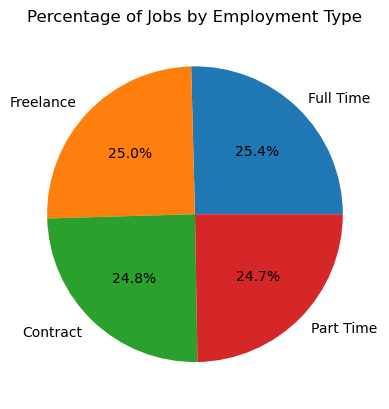

In [93]:
# 10.  What percentage of jobs are: • Full-time • Part-time • Contract • Freelance

percentage_wise_job_type = (df['employment_type'].value_counts(normalize=True) * 100).round(2)

plt.figure()
plt.pie(
    percentage_wise_job_type,
    labels=percentage_wise_job_type.index,
    autopct='%1.1f%%'
)
plt.title("Percentage of Jobs by Employment Type")
plt.show()


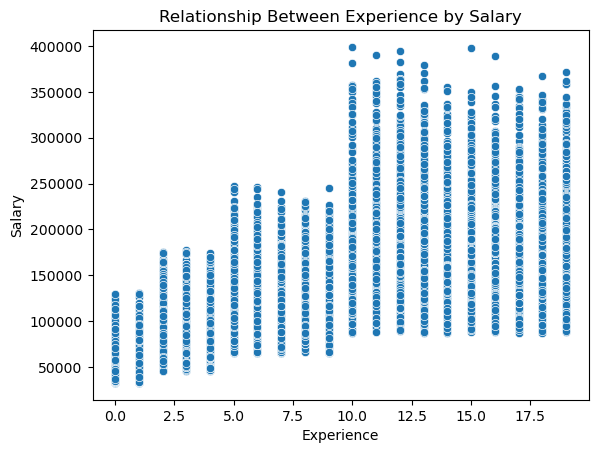

In [20]:
# 11. What is the relationship between: • Years of experience • Salary

plt.figure()
sns.scatterplot(x='years_experience', y="salary_usd", data=df)
plt.title('Relationship Between Experience by Salary')
plt.xlabel('Experience')
plt.ylabel('Salary')
plt.show()

In [21]:
# 12. What is the minimum experience required for: • AI Software Engineer • NLP Engineer • Data Scientist 

roles = ['AI Software Engineer', 'NLP Engineer', 'Data Scientist']
filtered_df = df[df['job_title'].isin(roles)]
min_experience = filtered_df.groupby('job_title')['years_experience'].min()
print(min_experience)

job_title
AI Software Engineer    0
Data Scientist          0
NLP Engineer            0
Name: years_experience, dtype: int64


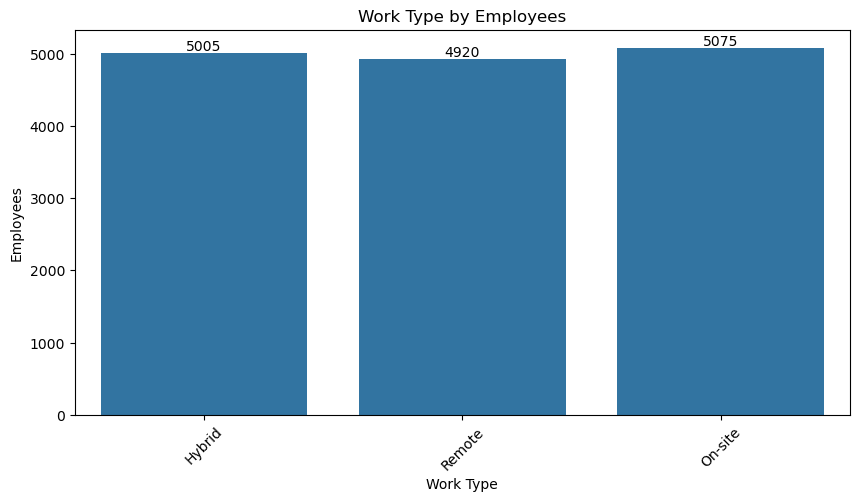

In [22]:
# 13. How many jobs are: • Remote • Hybrid • On-site
plt.figure(figsize=(10,5))
ax = sns.countplot(x='work_type', data=df)
ax.bar_label(ax.containers[0])
plt.title('Work Type by Employees')
plt.xlabel('Work Type')
plt.ylabel('Employees')
plt.xticks(rotation=45)
plt.show()

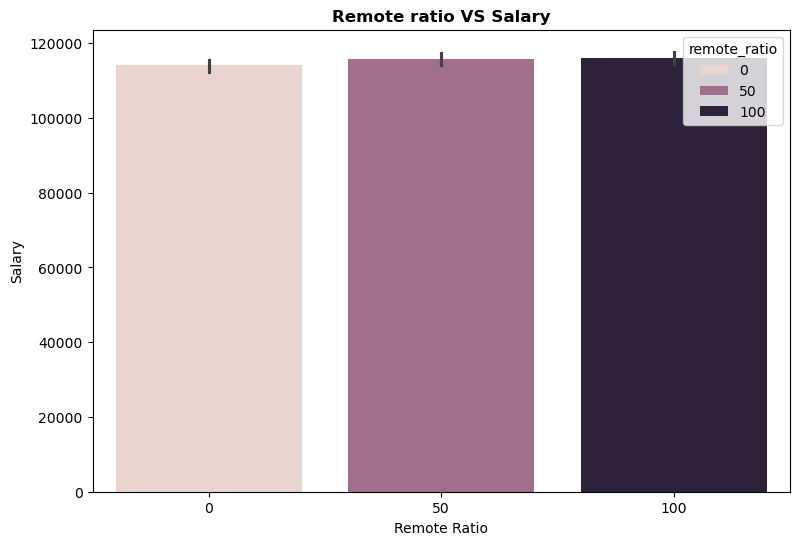

In [92]:
# 14. Does remote_ratio affect salary?  

plt.figure(figsize=(9,6))
sns.barplot(x='remote_ratio', y='salary_usd', hue='remote_ratio', data=df)
plt.title('Remote ratio VS Salary', fontweight='bold')
plt.xlabel('Remote Ratio')
plt.ylabel('Salary')
plt.show()

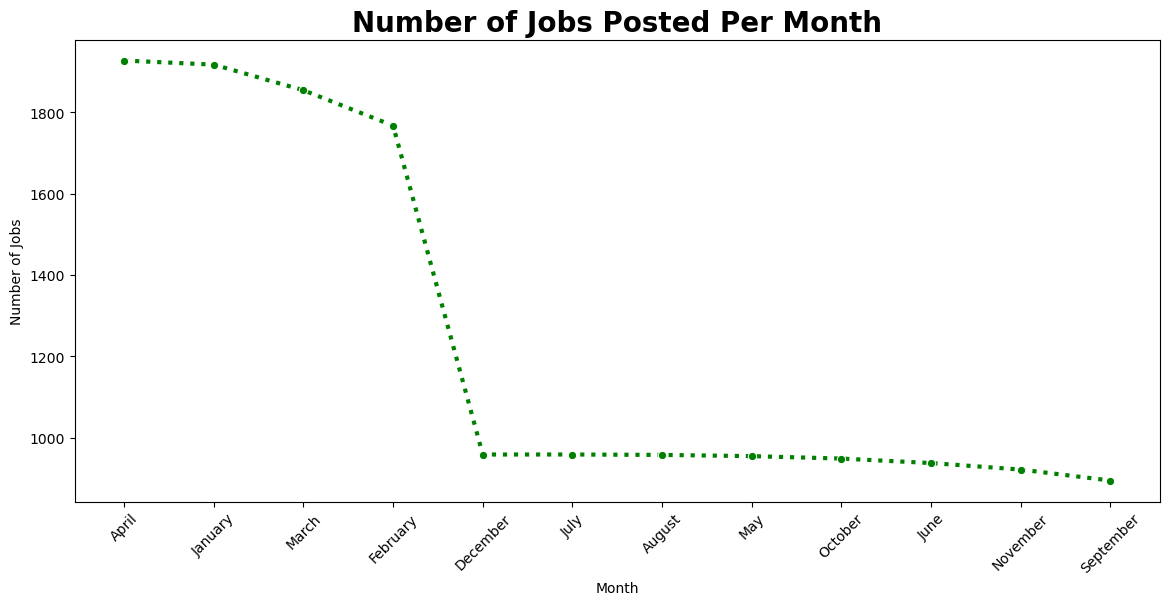

In [94]:
# 15. How many jobs are posted per month? 

df['month'] = df['posting_date'].dt.month_name()
jobs_per_month = df['month'].value_counts()

plt.figure(figsize=(14,6))
sns.lineplot(x=jobs_per_month.index, y=jobs_per_month.values,color='green', marker = 'o', linewidth=3, linestyle=':')
plt.title("Number of Jobs Posted Per Month", fontsize=20, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=45)
plt.show()

In [32]:
# 16.  What is the average time between posting_date and application_deadline?  

df['days_to_deadline'] = (
    df['application_deadline'] - df['posting_date']
).dt.days

df_clean = df.dropna(subset=['application_deadline'])

average_days = df_clean['days_to_deadline'].mean()
print("Average time between posting and deadline:", round(average_days,2), "days")

Average time between posting and deadline: 62.28 days


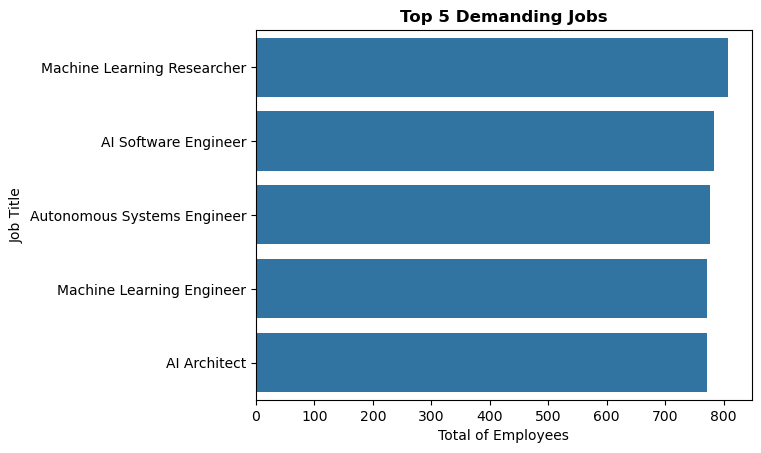

In [89]:
# 16. What are 5 demanding jobs

demand_job = df.groupby('job_title')['job_title'].value_counts().sort_values(ascending=False).head(5)

sns.barplot(x=demand_job.values, y=demand_job.index)
plt.title('Top 5 Demanding Jobs', fontweight='bold')
plt.xlabel('Total of Employees')
plt.ylabel('Job Title')
plt.show()